# Two-Tower Recommender on MovieLens

Двухбашенная retrieval-модель с нуля: эмбеддинги юзера и фильма, близость = дот-продукт, обучение in-batch softmax.

## 0. Импорты и загрузка данных

In [3]:
import pandas as pd
import random
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import copy
%matplotlib inline

In [6]:
import kagglehub
dataset_path = kagglehub.dataset_download('abhikjha/movielens-100k') + '/ml-latest-small'
print(dataset_path)

D:\kaggle_cache\datasets\abhikjha\movielens-100k\versions\1/ml-latest-small


## 1. Данные и разведка

MovieLens (ml-latest-small): 610 юзеров × 9724 фильма, разреженность ~1.7%.

In [7]:
movies = pd.read_csv(dataset_path + '/movies.csv')

In [8]:
ratings = pd.read_csv(dataset_path + '/ratings.csv')

In [9]:
ratings['userId'].value_counts()

userId
414    2698
599    2478
474    2108
448    1864
274    1346
       ... 
442      20
278      20
147      20
320      20
53       20
Name: count, Length: 610, dtype: int64

In [10]:
ratings['movieId'].value_counts()

movieId
356       329
318       317
296       307
593       279
2571      278
         ... 
160341      1
160527      1
160836      1
163937      1
135534      1
Name: count, Length: 9724, dtype: int64

In [11]:
user_count = len(ratings['userId'].drop_duplicates())

In [12]:
movie_count = len(ratings['movieId'].drop_duplicates())

In [13]:
ratings['rating'].value_counts()

rating
4.0    26818
3.0    20047
5.0    13211
3.5    13136
4.5     8551
2.0     7551
2.5     5550
1.0     2811
1.5     1791
0.5     1370
Name: count, dtype: int64

In [14]:
len(ratings)

100836

In [15]:
potential_ratings = user_count * movie_count
(len(ratings) / potential_ratings) * 100

1.6999683055613624

In [16]:
len(ratings[ratings['rating']>= 4.0])

48580

In [22]:
genres = movies['genres'].str.split('|').explode().unique()

In [23]:
movies_indexed = movies.set_index('movieId')
genres_df = movies_indexed['genres'].str.get_dummies('|').drop(columns=['(no genres listed)'], errors='ignore')
genres_df = genres_df.reset_index()

## 2. Постановка задачи

Позитивы = оценки ≥ 4.0. Негативы берём in-batch (непросмотренные фильмы других юзеров батча).

In [24]:
pos_ratings = ratings[ratings['rating']>= 4.0]

In [25]:
result = pd.merge(ratings, movies, on='movieId').drop(columns=['genres'])

In [26]:
pos_result = pd.merge(pos_ratings, movies, on='movieId').drop(columns=['genres'])

## 3. Перенумерация ID

Сырые userId/movieId → плотные индексы 0..N-1 для эмбеддинг-таблиц (как `stoi` в makemore).

In [27]:
userIds = result['userId'].drop_duplicates()
user2idx = {id: i for i, id in enumerate(userIds)}
movieIds = result['movieId'].drop_duplicates()
movie2idx = {id: i for i, id in enumerate(movieIds)}

In [28]:
result['userIdx'] = result['userId'].map(user2idx)
result['movieIdx'] = result['movieId'].map(movie2idx)

In [29]:
pos_result['userIdx'] = pos_result['userId'].map(user2idx)
pos_result['movieIdx'] = pos_result['movieId'].map(movie2idx)

In [30]:
genres_df['movieIdx'] = genres_df['movieId'].map(movie2idx)
genres_df = genres_df.dropna(subset=['movieIdx']).sort_values('movieIdx')
genre_cols = [c for c in genres_df.columns if c not in ('movieId', 'movieIdx')]
genres_tensor = torch.tensor(genres_df[genre_cols].values, dtype=torch.float32)

## 4. Split по времени (leave-last-out)

Внутри каждого юзера: ранние оценки → train, поздние → test. По времени, а не случайно — чтобы не было утечки будущего.

In [31]:
pos_result = pos_result.sort_values(by=['userIdx', 'timestamp'], ascending=[True, True])

In [32]:
pos_result['row_num'] = pos_result.groupby('userIdx').cumcount()

In [33]:
user_sizes = pos_result.groupby('userIdx').size().reset_index(name='total_count')

In [34]:
pos_result = pd.merge(pos_result, user_sizes, on='userIdx')

In [35]:
pos_result['pct_position'] = pos_result['row_num'] / pos_result['total_count']

In [36]:
train = pos_result[pos_result['pct_position'] < 0.80].copy()
val = pos_result[(pos_result['pct_position'] >= 0.80) & (pos_result['pct_position'] < 0.90)].copy()
test = pos_result[pos_result['pct_position'] >= 0.90].copy()

In [37]:
columns_to_drop = ['row_num', 'total_count', 'pct_position']
train.drop(columns=columns_to_drop, inplace=True)
val.drop(columns=columns_to_drop, inplace=True)
test.drop(columns=columns_to_drop, inplace=True)

## 5. Модель - две башни

Две `nn.Embedding` таблицы (n_dim=32). score = (u · m) / √d.

In [38]:
n_dim = 32
g = torch.Generator().manual_seed(2147483647)

class UserTower(nn.Module):
    def __init__(self, num_users, n_dim):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, n_dim)
    def forward(self, user_ix):
        return self.user_emb(user_ix)

class ItemTower(nn.Module):
    def __init__(self, num_movies, genres_tensor, n_dim, p_drop=0.3):
        super().__init__()
        n_genres = genres_tensor.shape[1]
        self.movie_emb = nn.Embedding(num_movies, n_dim)
        self.genre_W   = nn.Linear(n_genres, n_dim, bias=False)   # genre embeddings
        self.dropout   = nn.Dropout(p_drop)                       # regularization
        self.proj      = nn.Linear(2 * n_dim, n_dim)
        self.register_buffer('genres', genres_tensor)
    def forward(self, movie_ix):
        id_emb    = self.movie_emb(movie_ix)
        genre_emb = self.genre_W(self.genres[movie_ix])
        x = torch.cat([id_emb, genre_emb], dim=1)                 # (N, 2d)
        x = self.dropout(x)                                       # drop parts (train only)
        return self.proj(x)                                       # (N, d)

user_tower = UserTower(len(user2idx), n_dim)
item_tower = ItemTower(len(movie2idx), genres_tensor, n_dim)

## 6. Обучение (in-batch softmax)

scores = U @ Mᵀ, диагональ = позитивы, остальное = негативы. Loss = cross-entropy.

In [39]:
train_users  = torch.tensor(train['userIdx'].values)
train_movies = torch.tensor(train['movieIdx'].values)

In [40]:
LR = 1e-3
params = list(user_tower.parameters()) + list(item_tower.parameters())
optimizer = Adam(params, lr=LR, weight_decay=1e-4)   # weight_decay = L2 regularization

Q = (train['movieIdx'].value_counts() / len(train)).reindex(range(len(movieIds)), fill_value=0)
Q = torch.tensor(Q.values, dtype=torch.float32)

In [159]:
import copy

val_users_all  = torch.tensor(val['userIdx'].values)
val_movies_all = torch.tensor(val['movieIdx'].values)
g_val = torch.Generator().manual_seed(0)
val_ix = torch.randint(0, len(val_users_all), (1024,), generator=g_val)
val_u = val_users_all[val_ix]
val_m = val_movies_all[val_ix]

@torch.no_grad()
def compute_val_loss():
    uv = user_tower(val_u)
    mv = item_tower(val_m)
    s = (uv @ mv.T) / math.sqrt(n_dim) - torch.log(Q[val_m].clamp(min=1e-9))
    return F.cross_entropy(s, torch.arange(len(val_u))).item()

max_steps = 200000
batch_size = 256
lossi = []
best_val = float('inf')
best_state = None

for i in range(max_steps):
    user_tower.train(); item_tower.train()               # dropout ON for training
    ix = torch.randint(0, train.shape[0], (batch_size,), generator=g)
    user_idx_b, movie_idx_b = train_users[ix], train_movies[ix]
    log_q = torch.log(Q[movie_idx_b])

    uv = user_tower(user_idx_b)
    mv = item_tower(movie_idx_b)
    scores = (uv @ mv.T) / math.sqrt(n_dim) - log_q
    labels = torch.arange(batch_size)
    loss = F.cross_entropy(scores, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 10000 == 0:
        user_tower.eval(); item_tower.eval()             # dropout OFF for val
        vl = compute_val_loss()
        print(f'{i:7d}/{max_steps:7d}  train {loss.item():.4f}  val {vl:.4f}')
        if vl < best_val:
            best_val = vl
            best_state = {'user': copy.deepcopy(user_tower.state_dict()),
                          'item': copy.deepcopy(item_tower.state_dict())}
    lossi.append(loss.log10().item())

print(f'{max_steps:7d}/{max_steps:7d}  train {loss.item():.4f}  val {vl:.4f}')
user_tower.load_state_dict(best_state['user'])
item_tower.load_state_dict(best_state['item'])
print(f'best val loss: {best_val:.4f}')

      0/ 200000  train 6.6669  val 16.1989


  10000/ 200000  train 4.7931  val 14.4151


  20000/ 200000  train 4.5077  val 14.7299


  30000/ 200000  train 4.3203  val 14.8640


  40000/ 200000  train 4.4028  val 14.9248


...

 160000/ 200000  train 4.2120  val 15.0193


 170000/ 200000  train 4.3829  val 15.0060


 180000/ 200000  train 4.3209  val 15.0281


 190000/ 200000  train 4.2369  val 15.0213


 200000/ 200000  train 4.2316  val 15.0213
best val loss: 14.4151


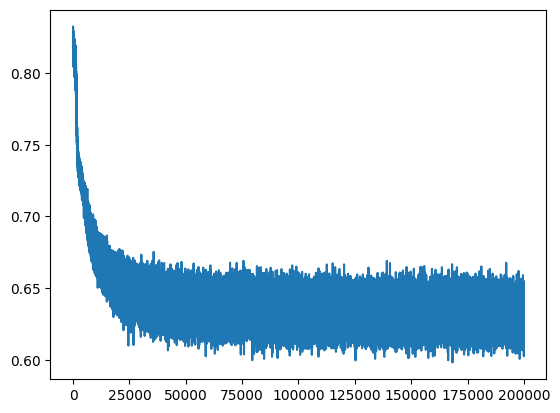

In [160]:
plt.plot(lossi)
plt.show()

## 7. Оценка - Recall@K

Тест-позитив ранжируется среди непросмотренных; доля попавших в топ-K. Baseline (случайно) ≈ 0.9%.

> **Note on the number below (~19%).** This is a *single* training run. A 5-seed test (`rigor_bestmodel.py`) showed the model does **not** reliably beat the ~17% mean - this run just landed high. See README, Experiment 4. The honest headline is ~17% (mean over seeds).

In [44]:
#Recall@K
user_tower.eval(); item_tower.eval()                     # dropout OFF for eval
with torch.no_grad():
    all_items = item_tower(torch.arange(len(movie2idx)))  # all movies through the item tower

test_users = torch.tensor(test['userIdx'].drop_duplicates().tolist())
sum_of_recall = 0.0
with torch.no_grad():
    for user in test_users:
        uv = user_tower(user)
        scores = uv @ all_items.T
        scores[torch.tensor(train['movieIdx'][train['userIdx'] == user.item()].values)] = float('-inf')
        _, indices = torch.topk(scores, k=50)
        test_movies = torch.tensor(test['movieIdx'][test['userIdx'] == user.item()].values)
        sum_of_recall += len(set(indices.tolist()) & set(test_movies.tolist())) / len(test_movies)

recall = sum_of_recall / len(test_users)
recall

0.20078660476661342

## 8. Сохранение модели

Веса обеих башен + словари user2idx/movie2idx в одном чекпоинте.

In [1]:
checkpoint = {
    'user_tower': user_tower.state_dict(),
    'item_tower': item_tower.state_dict(),
    'user2idx': user2idx,
    'movie2idx': movie2idx,
    'n_dim': n_dim,
}

NameError: name 'user_tower' is not defined

In [165]:
torch.save(checkpoint, 'model_and_dicts.pt')

In [42]:
ckpt = torch.load('model_and_dicts.pt')
user2idx = ckpt['user2idx']
movie2idx = ckpt['movie2idx']
n_dim = ckpt['n_dim']

n_genres = ckpt['item_tower']['genre_W.weight'].shape[1]
genres_shape = torch.zeros(len(movie2idx), n_genres)

user_tower = UserTower(len(user2idx), n_dim)
item_tower = ItemTower(len(movie2idx), genres_shape, n_dim)

user_tower.load_state_dict(ckpt['user_tower'])
item_tower.load_state_dict(ckpt['item_tower'])  

user_tower.eval()
item_tower.eval() 


ItemTower(
  (movie_emb): Embedding(9724, 32)
  (genre_W): Linear(in_features=19, out_features=32, bias=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (proj): Linear(in_features=64, out_features=32, bias=True)
)